In [1]:
import numpy as np
import scipy
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py
from localized_2d import WfnParams, Wavefunction, HamiltParams, Hamilt

In [2]:
%%capture
%run vgh_2d_analysis.ipynb

TODO: 

- compare the energies from the tunneling matrix with the energies that we have

In [438]:
def get_e_loc_for_coupling(dir,Mx,My,tx,ty,B,V_0_arr):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_arr_tun = np.zeros(len(V_0_arr), dtype=complex)
    
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        V_0 = V_0_arr[i]
        file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

        with h5py.File(file_path, 'r') as f:
            phi_data = f["wfn"][...]
            Mx = f["Mx"][...]
            My = f["My"][...]
            n = f["n"][...]
            B = f["B"][...]
            tx = f["tx"][...]
            ty = f["ty"][...]
            V_0 = f["V0"][...]
            e_tun = f["e_tun"][...]
            v_tun = f["v_tun"][...]

        wfnpar = WfnParams(Mx, My, n)
        Mx, My, n, x, k2 = wfnpar.read()

        wfn = Wavefunction(wfnpar, array=phi_data)

        hamiltpar = HamiltParams(B, tx, ty, V_0)

        H = Hamilt(wfnpar, hamiltpar)
        energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
        Tx, Ty = H.calc_Tx_Ty(wfn)
        
        e_arr[i] = energy_tot
        e_T_arr[i] = energy_ele
        e_B_arr[i] = np.sum(energy_rot)
        e_V_arr[i] = np.sum(energy_int)

        e_arr_tun[i] = e_tun[0]

        Tx_arr[i] = Tx
        Ty_arr[i] = Ty
        
    return e_arr, e_arr_tun, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_state_e_loc_data(dir,Mx,My,tx_arr,ty_arr,B,V_0_arr):
    e_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_tun_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)

    e_T_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_B_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    e_V_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    
    Tx_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    Ty_arr = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    for i in range(len(tx_arr)):
        tx = tx_arr[i]
        ty = ty_arr[i]

        e_flp, e_tun, e_flp_T, e_flp_B, e_flp_V, Tx_flp, Ty_flp = get_e_loc_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0_arr=V_0_arr)

        e_arr[i] = e_flp
        e_tun_arr[i] = e_tun 
        
        e_T_arr[i] = e_flp_T
        e_B_arr[i] = e_flp_B
        e_V_arr[i] = e_flp_V


        Tx_arr[i] = Tx_flp
        Ty_arr[i] = Ty_flp

    return e_arr, e_tun_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_wfn_loc_for_coupling(dir,Mx,My,tx,ty,B,V_0):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_arr_tun = np.zeros(len(V_0_arr), dtype=complex)
    
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        e_tun = f["e_tun"][...]
        v_tun = f["v_tun"][...]

    wfnpar = WfnParams(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    wfn = Wavefunction(wfnpar, array=phi_data)

    hamiltpar = HamiltParams(B, tx, ty, V_0)

    H = Hamilt(wfnpar, hamiltpar)
    energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
    Tx, Ty = H.calc_Tx_Ty(wfn)

    return x, wfn.rotwfn, wfn.elewfn, energy_tot, energy_ele, energy_rot, energy_int, Tx, Ty

def Px_Py_rotwfn(x,Mx,My,phi_data):
    P_arr = np.zeros((My,Mx), dtype=complex)
    Px_arr = np.zeros((My,Mx), dtype=complex)
    Py_arr = np.zeros((My,Mx), dtype=complex)
    for i in range(My):
        for j in range(Mx):
            Px = np.sum(np.cos(x)*np.abs(phi_data[i,j,:])**2) 
            Py = np.sum(np.sin(x)*np.abs(phi_data[i,j,:])**2)

            P_arr[i,j] = (Px**2 + Py**2)**0.5
            Px_arr[i,j] = Px
            Py_arr[i,j] = Py

    return P_arr, Px_arr, Py_arr

In [4]:
def get_loc_matrix_for_coupling(dir,Mx,My,tx,ty,B,V_0):
    file_path = dir+'data_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'
    
    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        e_tun = f["e_tun"][...]
        v_tun = f["v_tun"][...]
        
    wfnpar = WfnParams(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    wfn = Wavefunction(wfnpar, array=phi_data)

    hamiltpar = HamiltParams(B, tx, ty, V_0)

    H = Hamilt(wfnpar, hamiltpar)
    energy_tot, energy_rot, energy_ele, energy_int = H.calculate_energy(wfn)
    #Tx, Ty = H.calc_Tx_Ty(wfn)
    H, B = H.calculate_tunnelings(wfn)
    
    return H, B

def get_pbc_index(M):
    kmu = np.arange(Mx)
    kmu[kmu > M/2] = -(kmu[kmu > M/2]%(M/2))[::-1]
    return kmu

def get_ope_fourier(Mx,My,Op):
    return np.einsum('ij->', Op)
    
def get_first_deriv_ope_fourier(Mx,My,Op):
    kx = get_pbc_index(Mx)
    ky = get_pbc_index(My)

    dOp_dkx = np.einsum('ij,i->', Op, 1j*kx)
    dOp_dky = np.einsum('ij,j->', Op, 1j*ky)

    return dOp_dkx, dOp_dky
    
def get_sec_deriv_ope_fourier(Mx,My,Op):
    kx = get_pbc_index(Mx)
    ky = get_pbc_index(My)
    
    d2Op_dkx2 = np.einsum('ij,i->', Op, -kx**2)
    d2Op_dky2 = np.einsum('ij,j->', Op, -ky**2)

    return d2Op_dkx2, d2Op_dky2

def get_eff_mass(E_He,dHe_dk,d2He_dk2,S_psi,dS_dk,d2S_dk2):
    term1 = (1/S_psi)*d2He_dk2
    term2 = -2*(dHe_dk/S_psi**2)*dS_dk
    term3 = -(E_He/S_psi**2)*d2S_dk2
    term4 = 2*(E_He/S_psi**3)*dS_dk**2

    #print('\n',term1,term2,term3,term4,'\n')
    d2E_dk2 = term1+term2+term3+term4
    m = 1/d2E_dk2
    return m

def get_eff_mass_arr(tx_arr,ty_arr,V_0_arr,Mx,My,B):
    mx = np.zeros((len(tx_arr),len(V_0_arr)), dtype=complex)
    my = np.zeros((len(ty_arr),len(V_0_arr)), dtype=complex)
    dir = 'data_localized/'
    for j in range(len(tx_arr)):
        for i in range(len(V_0_arr)):
            tx = tx_arr[j]
            ty = ty_arr[j]
        
            H, S = get_loc_matrix_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0=V_0_arr[i])

            E_H = get_ope_fourier(Mx,My,H)
            dH_dkx, dH_dky = get_first_deriv_ope_fourier(Mx,My,H)
            d2H_dkx2, d2H_dky2 = get_sec_deriv_ope_fourier(Mx,My,H)
    
            S_psi = get_ope_fourier(Mx,My,S)
            dS_dkx, dS_dky = get_first_deriv_ope_fourier(Mx,My,S)
            d2S_dkx2, d2S_dky2 = get_sec_deriv_ope_fourier(Mx,My,S)

            mx[j,i] = get_eff_mass(E_H,dH_dkx,d2H_dkx2,S_psi,dS_dkx,d2S_dkx2)
            my[j,i] = get_eff_mass(E_H,dH_dky,d2H_dky2,S_psi,dS_dky,d2S_dky2) #(Mx*My)/np.sum(my2Hem)

            print('tx, ty, V_0, m_x, m_y =', tx_arr[j], ty_arr[j], V_0_arr[i], E_H, mx[j,i], my[j,i])

    return mx, my

# Energy Analysis

In [435]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.4])

Mx = 20
My = 20
tx = 0.5
ty = 0.5
B = 1e-2

dir = 'data_localized/'
e, e_tun, e_T, e_B, e_V, Tx, Ty = get_e_loc_for_coupling(dir=dir,Mx=Mx,My=My,tx=tx,ty=ty,B=B,V_0_arr=V_0_arr)

print('E     =', e, '\nE_tun =', e_tun, '\nE_T   =', e_T, '\nE_B   =', e_B, '\nE_V   =', e_V, '\nTx    =', Tx, '\nTy    =', Ty)

E     = [-2.2674772-1.13085789e-19j] 
E_tun = [-2.26918503-1.04877562e-19j] 
E_T   = [-1.4946766+0.j] 
E_B   = [0.11912462-1.13085789e-19j] 
E_V   = [-0.89192521+0.j] 
Tx    = [1.4946766+0.j] 
Ty    = [1.4946766+0.j]


In [439]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.4])

Mx = 20
My = 20
tx_arr = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B = 1e-2

qx=0.0
qy=0.0

dir='data_localized/'
e_arr, e_tun_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr = get_state_e_loc_data(dir=dir,Mx=Mx,My=My,tx_arr=tx_arr,ty_arr=ty_arr,B=B,V_0_arr=V_0_arr)

## Energy dependence of localized Ansatz on coupling strength

tx = 1.0  ty = 0.0


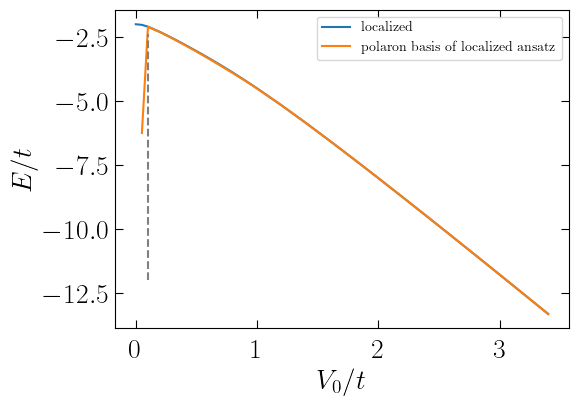

In [470]:
delta_t_index = 5
print('tx =', tx_arr[delta_t_index], ' ty =', ty_arr[delta_t_index])

plt.plot(V_0_arr, e_arr[delta_t_index].real, label=r'localized')
plt.plot(V_0_arr[1:], e_tun_arr[delta_t_index].real[1:], label=r'polaron basis of localized ansatz')

plt.vlines(x=0.1, ymin=-12, ymax=-2.4, linestyle='dashed', color='grey')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()

## Comparison localized Ansatz with translated localized basis

V_0 cuttoff = 0.3

Min delta E_loc - E_{trans-loc} = 7.413406555301094e-09
Max delta E_loc - E_{trans-loc} = 0.025312021545500496
Avg delta E_loc - E_{trans-loc} = 0.0034346695120838805


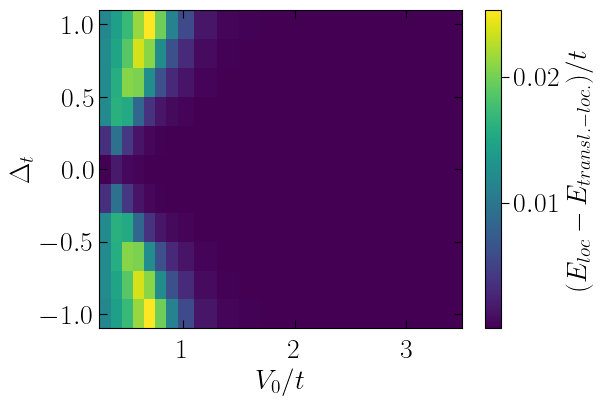

In [491]:
i_cutoff = 4
delta_e_loc_trans_loc = e_arr.real.T[i_cutoff:,].T - e_tun_arr.real.T[i_cutoff:,].T

print('V_0 cuttoff =', V_0_arr[i_cutoff])
print('\nMin delta E_loc - E_{trans-loc} =', np.min(delta_e_loc_trans_loc))
print('Max delta E_loc - E_{trans-loc} =', np.max(delta_e_loc_trans_loc))
print('Avg delta E_loc - E_{trans-loc} =', np.average(delta_e_loc_trans_loc))

X, Y = np.meshgrid(V_0_arr[i_cutoff:], tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,delta_e_loc_trans_loc, antialiased=False) # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,delta_e_loc_trans_loc, antialiased=False) # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$(E_{loc}-E_{transl.-loc.})/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

# Phase Diagram

## In $\Delta_t - V_0$ plane

### Interpolation

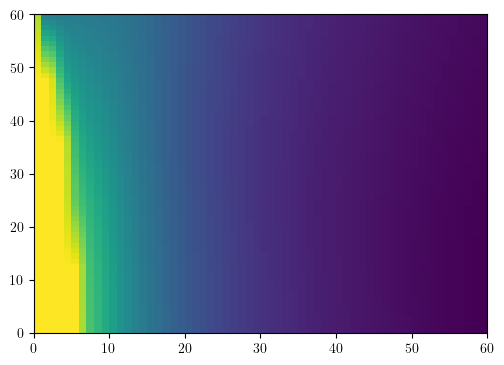

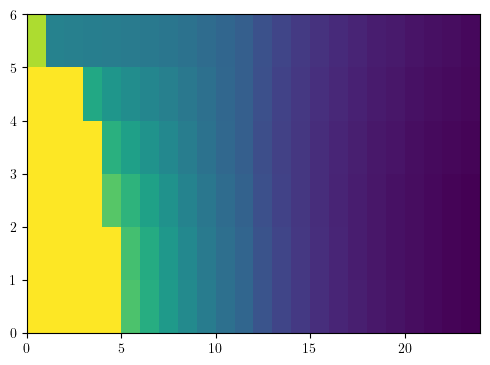

In [8]:
def interpolate_data_loc(x,y,x_points,y_points,data):    
    f = scipy.interpolate.RegularGridInterpolator((x.real, y.real), data.real, bounds_error=False, fill_value=None)
    
    Xnew = np.linspace(x[0].real, x[-1].real, x_points)
    Ynew = np.linspace(y[0].real, y[-1].real, y_points)
    Xnew, Ynew = np.meshgrid(Xnew, Ynew, indexing='ij')

    data_new = f((Xnew,Ynew), method='slinear')
    return Xnew, Ynew, data_new

def create_interp_array_loc(x,y,x_points,y_points,arr):
    arr_interp = np.zeros((4,x_points,y_points))
    
    X_intp, Y_intp, arr_interp = interpolate_data_loc(x,y,x_points,y_points,arr.real)
    
    return X_intp, Y_intp, arr_interp
    
delta_t = tx_arr-ty_arr
x_points = 60
y_points = 60

X_intp, Y_intp, e_arr_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,e_arr)
X_intp, Y_intp, Tx_arr_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,Tx_arr)
X_intp, Y_intp, Ty_arr_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,Ty_arr)

plt.pcolormesh(np.abs(Tx_arr_interp+Ty_arr_interp)); plt.show()
plt.pcolormesh(np.abs(Tx_arr+Ty_arr))

In [189]:
def plot_delta_t_phase_diagram(x,y,m_size,Tx,Ty,file_save):
    A = 6
    plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    font_size = 20 # 14

    fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

    y1 = -y.copy()

    x_points = len(x)
    y_points = len(y) 
    
    img1 = np.ones((y_points,x_points,3)) # image for upper half
    img2 = np.ones((y_points,x_points,3)) # image for lower half
    
    '''
    A very simple colormap:
    #  mapping parameter 1 to the red channel and 
    #          parameter 2 to the blue channel
    '''
    green_frac = 0.83
    cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))
    
    p1 = Tx
    p2 = Ty
    for j in range(len(y)):
        for i in range(len(x)):
            plt.plot(x[i], y[j], marker="s", markersize=m_size, color=cmap(p1[j,i],p2[j,i]))
            plt.plot(x[i], y1[j], marker="s", markersize=m_size, color=cmap(p2[j,i],p1[j,i]))

            img1[j,i] = cmap(p1[j,i],p2[j,i])
            img2[j,i] = cmap(p2[j,i],p1[j,i])

    ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.07, -0.051), fontsize=20, color='black')
    ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.5, 0.6), fontsize=20, color='black')
    ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.5, -0.7), fontsize=20, color='black')
    ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')
    plt.plot(np.array([0,0.612]), np.array([1,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0,0.612]), np.array([-1,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0.8375,1.7]), np.array([0,1]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0.8375,1.7]), np.array([0,-1]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
    plt.plot(np.array([0.6,0.84]), np.array([0,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)


    plt.xlim(0,2)
    plt.ylim(-1,1)

    plt.xlabel(r'$V_0/t$', fontsize=font_size)
    plt.ylabel(r'$\Delta_t$', fontsize=font_size)

    plt.xticks([0,0.5,1,1.5,1.75],[r'0.0',r'0.5',r'1.0',r'1.5',r''], fontsize=font_size)
    plt.yticks([-1,-0.5,0,0.5,1],[r'-1.0',r'-0.5',r'0.0',r'0.5',r'1.0'], fontsize=font_size)

    plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7) # 4
    plt.tick_params(axis='y', direction='in', length=6, right=True)

    plt.tick_params(which='minor', axis='y', direction='in', right=True)

    plt.subplots_adjust(left=0.1, right=0.65, top=0.85)
    cax = fig.add_axes([0.54,0.65,0.1,0.1]) #([0.54,0.7,0.1,0.1]) #fig.add_axes([0.72,0.55,0.3,0.3])
    cp1 = np.linspace(0, 1, 100)
    cp2 = np.linspace(0, 1, 100)
    Cp1, Cp2 = np.meshgrid(cp1,cp2)
    C0 = green_frac*np.ones_like(Cp2)
    # make RGB image, p1 to red channel, p2 to blue channel
    Legend = np.dstack(((1-Cp1)**(1/3),C0,(1-Cp2)**(1/3)))

    # parameters range between 0 and 1
    cax.imshow(Legend, origin="lower", extent=[0,2,0,2])
    cax.set_xticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_yticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_xlabel(r'$\mathcal{T}_x$', fontsize=0.75*font_size)
    cax.set_ylabel(r'$\mathcal{T}_y$', fontsize=0.75*font_size)

    plt.show()
    plt.savefig(file_save, bbox_inches='tight', dpi=500, transparent=True)
    return img1, img2

'''
This plotting routine just fills white gaps in the plot - can be useful for irregular grids!
'''
def plot_delta_t_phase_diagram_img(x,y,img1,img2,file_save):
    A = 6
    plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    font_size = 20 # 14

    fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

    Xgrid, Ygrid = np.meshgrid(y, x, indexing='ij')

    plt.pcolormesh(Ygrid, Xgrid, img1, antialiased=True, rasterized=True)
    plt.pcolormesh(Ygrid, -Xgrid, img2, antialiased=True, rasterized=True)

    ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.07, -0.051), fontsize=20, color='black')
    ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.5, 0.6), fontsize=20, color='black')
    ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.5, -0.7), fontsize=20, color='black')
    ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')

    plt.xlim(0,2)
    plt.ylim(-1,1)

    plt.xlabel(r'$V_0/t$', fontsize=font_size)
    plt.ylabel(r'$\Delta_t$', fontsize=font_size)

    plt.xticks([0,0.5,1,1.5,1.75],[r'0.0',r'0.5',r'1.0',r'1.5',r''], fontsize=font_size)
    plt.yticks([-1,-0.5,0,0.5,1],[r'-1.0',r'-0.5',r'0.0',r'0.5',r'1.0'], fontsize=font_size)

    plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7) # 4
    plt.tick_params(axis='y', direction='in', length=6, right=True)

    plt.tick_params(which='minor', axis='y', direction='in', right=True)

    plt.subplots_adjust(left=0.1, right=0.65, top=0.85)
    cax = fig.add_axes([0.54,0.65,0.1,0.1]) #([0.54,0.7,0.1,0.1]) #fig.add_axes([0.72,0.55,0.3,0.3])
    cp1 = np.linspace(0, 1, 100)
    cp2 = np.linspace(0, 1, 100)
    Cp1, Cp2 = np.meshgrid(cp1,cp2)
    C0 = green_frac*np.ones_like(Cp2)
    # make RGB image, p1 to red channel, p2 to blue channel
    Legend = np.dstack(((1-Cp1)**(1/3),C0,(1-Cp2)**(1/3)))

    # parameters range between 0 and 1
    cax.imshow(Legend, origin="lower", extent=[0,2,0,2])
    cax.set_xticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_yticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_xlabel(r'$\mathcal{T}_x$', fontsize=0.75*font_size)
    cax.set_ylabel(r'$\mathcal{T}_y$', fontsize=0.75*font_size)

    plt.savefig(file_save, bbox_inches='tight', dpi=500, transparent=True)

### Plotting the Energy

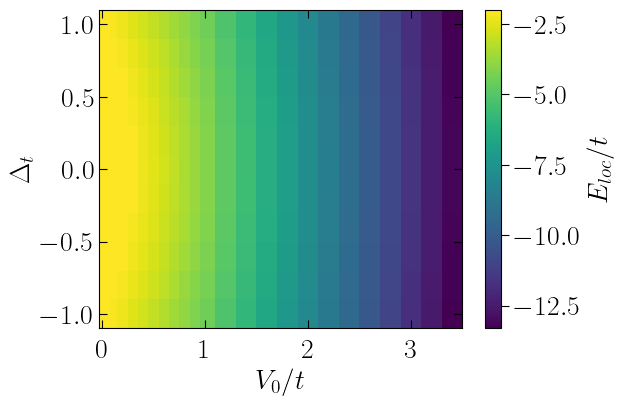

In [10]:
'''Raw Data without Interpolation'''
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_arr.real, antialiased=False) # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_arr.real, antialiased=False) # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$E_{loc}/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

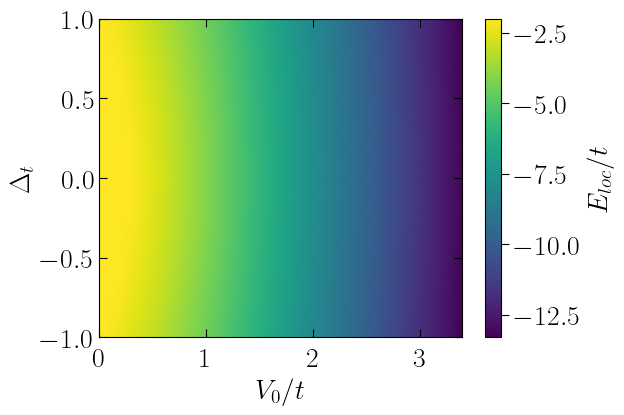

In [11]:
'''With Interpolation'''
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_arr.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_arr.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$E_{loc}/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.savefig('img_results/energy_localized_interp.svg', bbox_inches='tight', dpi=500, transparent=True)

### Plotting the Order Parameter

/tmp/ipykernel_4194073/265488655.py:24: RuntimeWarning: invalid value encountered in scalar power
  cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))


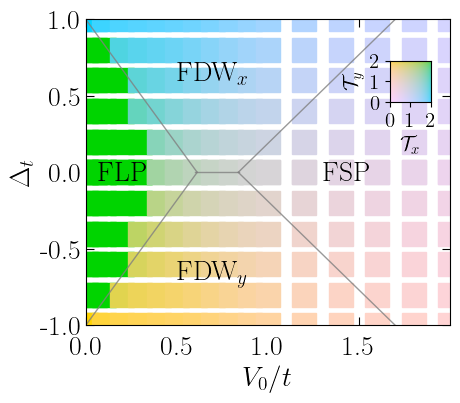

/tmp/ipykernel_4194073/265488655.py:24: RuntimeWarning: invalid value encountered in scalar power
  cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))


<Figure size 585.25x413.875 with 0 Axes>

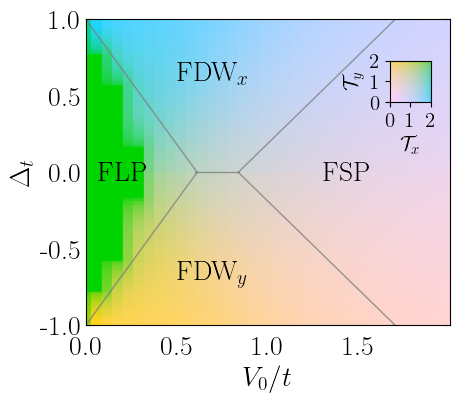

<Figure size 585.25x413.875 with 0 Axes>

In [190]:
delta_t = tx_arr-ty_arr
img1, img2 = plot_delta_t_phase_diagram(x=V_0_arr,y=delta_t,m_size=17,Tx=Tx_arr,Ty=Ty_arr,file_save='img_results/pd_loc_delta_t_B_1e-2t.png')

x_intp = np.linspace(V_0_arr[0], V_0_arr[-1], x_points)
y_intp = np.linspace(delta_t[0], delta_t[-1], y_points)

img1_intp, img2_intp = plot_delta_t_phase_diagram(x=x_intp,y=y_intp,m_size=7,Tx=Tx_arr_interp,Ty=Ty_arr_interp,file_save='img_results/pd_intp_loc_V0_delta_t_B_1e-2t.svg')

### Detail of Order Parameter

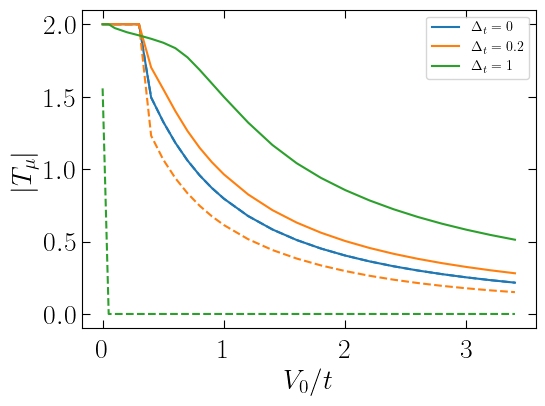

In [13]:
i = 0
plt.plot(V_0_arr, Tx_arr[i].real, linestyle='solid', color='tab:blue', label=r'$\Delta_t = 0$')
plt.plot(V_0_arr, Ty_arr[i].real, linestyle='dashed', color='tab:blue')

i = 1
plt.plot(V_0_arr, Tx_arr[i].real, linestyle='solid', color='tab:orange', label=r'$\Delta_t = 0.2$')
plt.plot(V_0_arr, Ty_arr[i].real, linestyle='dashed', color='tab:orange')

i = 5
plt.plot(V_0_arr, Tx_arr[i].real, linestyle='solid', color='tab:green', label=r'$\Delta_t = 1$')
plt.plot(V_0_arr, Ty_arr[i].real, linestyle='dashed', color='tab:green')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$|T_{\mu}|$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
plt.savefig('img_results/pd_loc_order_parameter.svg', bbox_inches='tight', dpi=500, transparent=True)

# Comparison vGH - Localized

## Energy Comparison

In [14]:
'''
vGH: Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_vgh = np.array([0.0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.4])

Mx_vgh = 10
My_vgh = 10
tx_arr_vgh = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_vgh = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B_vgh = 1e-2

qx_vgh=0.0
qy_vgh=0.0

dir='data_vgh/'
e_arr_vgh, e_T_arr_vgh, e_B_arr_vgh, e_V_arr_vgh, Tx_arr_vgh, Ty_arr_vgh = get_state_e_vgh_data(dir=dir,Mx=Mx_vgh,My=My_vgh,tx_arr=tx_arr_vgh,ty_arr=ty_arr_vgh,qx=qx_vgh,qy=qx_vgh,B=B_vgh,V_0_arr=V_0_arr_vgh)
e_gs_vgh, Tx_gs_vgh, Ty_gs_vgh = get_gs_phase_diagram(e_arr_vgh,Tx_arr_vgh,Ty_arr_vgh)

e_diff = e_gs_vgh - e_arr

print('Shape E_gs_loc, Shape E_gs_vgh =', e_arr.shape, ',', e_gs_vgh.shape)

Shape E_gs_loc, Shape E_gs_vgh = (6, 24) , (6, 24)


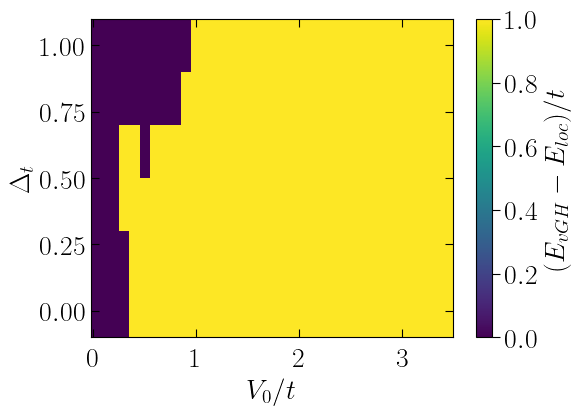

In [15]:
e_diff_heav = np.zeros(e_diff.shape)
for i in range(e_diff.shape[0]):
    for j in range(e_diff.shape[1]):
        if e_diff.real[i,j] > 0:
            e_diff_heav[i,j] = 1
        else:
            e_diff_heav[i,j] = 0

X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_diff_heav.real, antialiased=False) #, shading='gouraud') # cmap='gnuplot',
#pc = plt.pcolormesh(X,-Y,e_diff.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$(E_{vGH}-E_{loc})/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
#plt.savefig('img_results/diff_vgh_loc_mesh.svg', bbox_inches='tight', dpi=500, transparent=True)

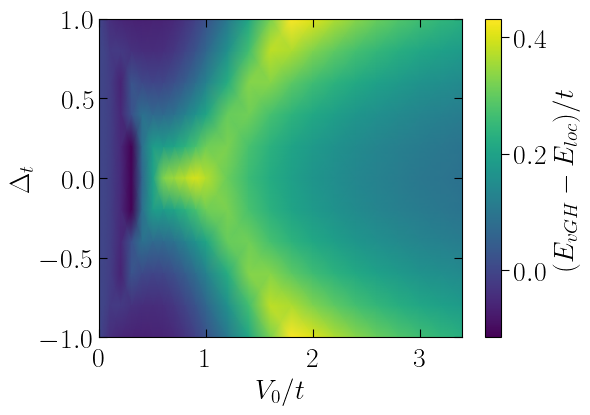

In [16]:
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_diff.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_diff.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$(E_{vGH}-E_{loc})/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
plt.savefig('img_results/diff_vgh_loc_mesh.svg', bbox_inches='tight', dpi=500, transparent=True)

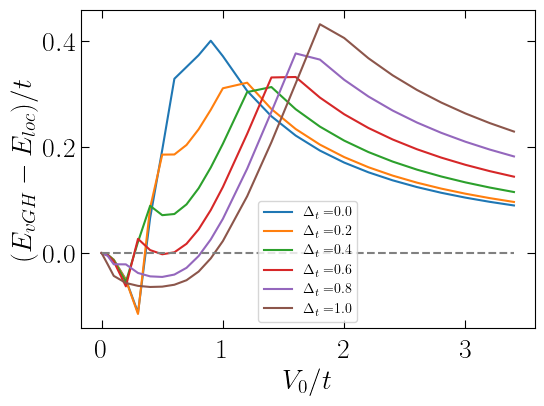

In [17]:
for i in range(e_diff.shape[0]):
    plt.plot(V_0_arr, e_diff[i].real, label=r'$\Delta_t = $'+str(round((tx_arr-ty_arr)[i],1)))

plt.hlines(y=0, xmin=V_0_arr[0], xmax=V_0_arr[-1], linestyle='dashed', color='grey')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$(E_{vGH}-E_{loc})/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
plt.savefig('img_results/diff_vgh_loc_lines.svg', bbox_inches='tight', dpi=500, transparent=True)

### vGH versus translated localized

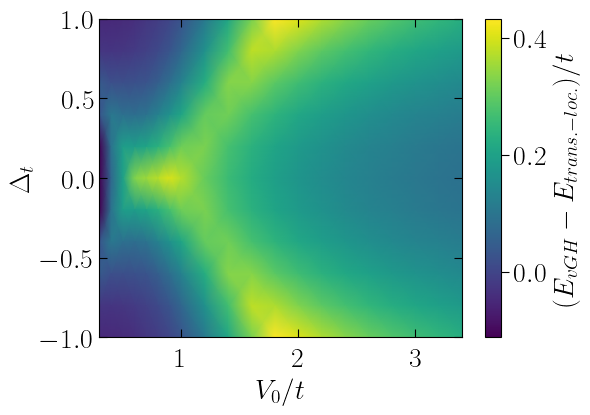

In [493]:
X, Y = np.meshgrid(V_0_arr[i_cutoff:], tx_arr-ty_arr)

pc = plt.pcolormesh(X,Y,e_diff_vgh_trans_loc.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,e_diff_vgh_trans_loc.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$(E_{vGH}-E_{trans.-loc.})/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
#plt.savefig('img_results/diff_vgh_loc_mesh.svg', bbox_inches='tight', dpi=500, transparent=True)


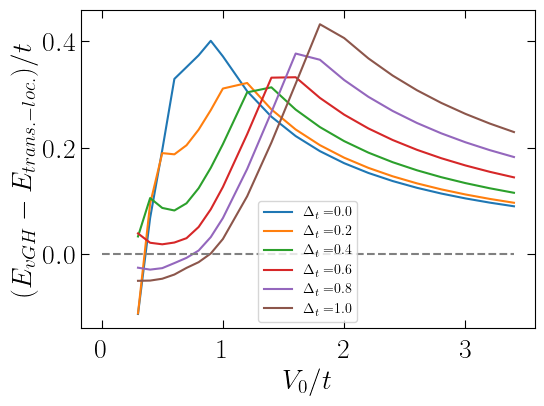

In [494]:
for i in range(e_diff.shape[0]):
    plt.plot(V_0_arr[i_cutoff:], e_diff_vgh_trans_loc[i].real, label=r'$\Delta_t = $'+str(round((tx_arr-ty_arr)[i],1)))

plt.hlines(y=0, xmin=V_0_arr[0], xmax=V_0_arr[-1], linestyle='dashed', color='grey')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$(E_{vGH}-E_{trans.-loc.})/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
#plt.savefig('img_results/diff_vgh_loc_lines.svg', bbox_inches='tight', dpi=500, transparent=True)

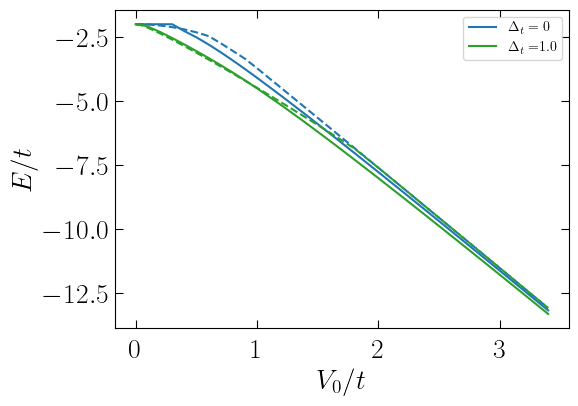

In [138]:
i = 0
plt.plot(V_0_arr, e_arr[i].real, linestyle='solid', color='tab:blue', label=r'$\Delta_t = 0$')
plt.plot(V_0_arr_vgh, e_gs_vgh[i].real, linestyle='dashed', color='tab:blue')

i = 5
plt.plot(V_0_arr, e_arr[i].real, linestyle='solid', color='tab:green', label=r'$\Delta_t = $'+str(round((tx_arr-ty_arr)[i],1)))
plt.plot(V_0_arr_vgh, e_gs_vgh[i].real, linestyle='dashed', color='tab:green')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()
plt.savefig('img_results/comp_vgh_loc_energies.svg', bbox_inches='tight', dpi=500, transparent=True)

## Phase Diagram combining vGH and localized

In [179]:
Tx_vgh_loc = np.zeros(Tx_gs_vgh.shape, dtype=complex)
Ty_vgh_loc = np.zeros(Ty_gs_vgh.shape, dtype=complex)

e_vgh_loc = np.zeros(e_gs_vgh.shape, dtype=complex)

for i in range(Tx_gs_vgh.shape[0]):
    for j in range(Tx_gs_vgh.shape[1]):
        if e_gs_vgh[i,j] <= e_arr[i,j]:
            e_vgh_loc[i,j] = e_gs_vgh[i,j]
            Tx_vgh_loc[i,j] = -Tx_gs_vgh[i,j]
            Ty_vgh_loc[i,j] = -Ty_gs_vgh[i,j]
            #print(V_0_arr[j], delta_t[i])
        elif e_gs_vgh[i,j] > e_arr[i,j]:
            e_vgh_loc[i,j] = e_arr[i,j]
            Tx_vgh_loc[i,j] = Tx_arr[i,j]
            Ty_vgh_loc[i,j] = Ty_arr[i,j]

delta_t = tx_arr-ty_arr
x_points = 60
y_points = 60

X_intp, Y_intp, e_vgh_loc_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,e_vgh_loc)
X_intp, Y_intp, Tx_vgh_loc_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,Tx_vgh_loc)
X_intp, Y_intp, Ty_vgh_loc_interp = create_interp_array_loc(delta_t,V_0_arr,x_points,y_points,Ty_vgh_loc)

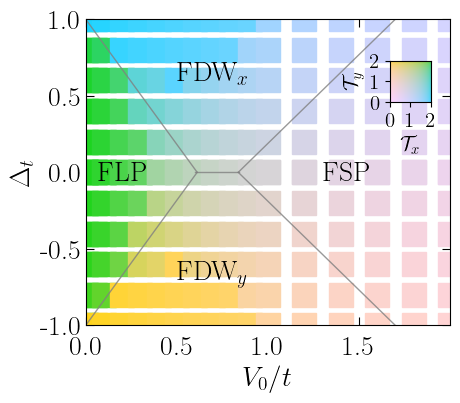

/tmp/ipykernel_4194073/265488655.py:24: RuntimeWarning: invalid value encountered in scalar power
  cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))


<Figure size 585.25x413.875 with 0 Axes>

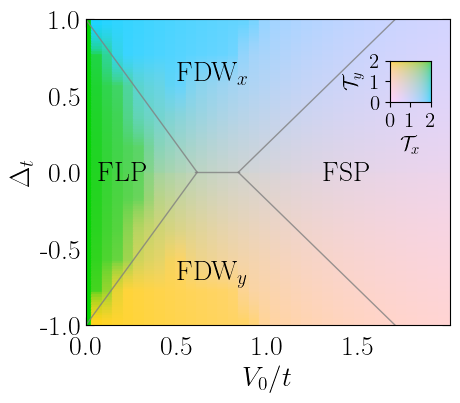

<Figure size 585.25x413.875 with 0 Axes>

In [192]:
delta_t = tx_arr-ty_arr
img1, img2 = plot_delta_t_phase_diagram(x=V_0_arr,y=delta_t,m_size=17,Tx=Tx_vgh_loc,Ty=Ty_vgh_loc,file_save='img_results/pd_vgh_loc_delta_t_B_1e-2t.png')

x_intp = np.linspace(V_0_arr[0], V_0_arr[-1], x_points)
y_intp = np.linspace(delta_t[0], delta_t[-1], y_points)

img1_intp, img2_intp = plot_delta_t_phase_diagram(x=x_intp,y=y_intp,m_size=7,Tx=Tx_vgh_loc_interp,Ty=Ty_vgh_loc_interp,file_save='img_results/pd_intp_vgh_loc_V0_delta_t_B_1e-2t.pdf')

/mnt/nfs/clustersw/Debian/bookworm/jupyterhub/1.0/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/nfs/clustersw/Debian/bookworm/jupyterhub/1.0/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


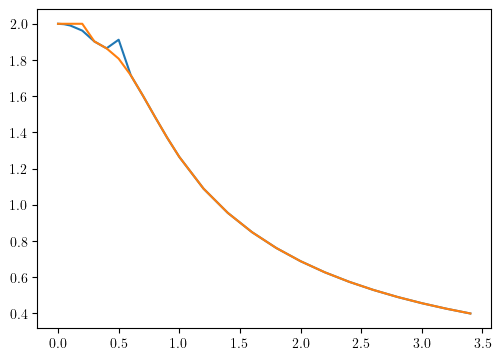

In [181]:
plt.plot(V_0_arr, Tx_vgh_loc[3])
plt.plot(V_0_arr, Tx_arr[3])

## Jahn-Teller Scan in Asymmetry Parameter
### Scan in $\Delta_t$

Quadratic Fit:          2
-0.4449 x - 3.752
V0 =  0.9


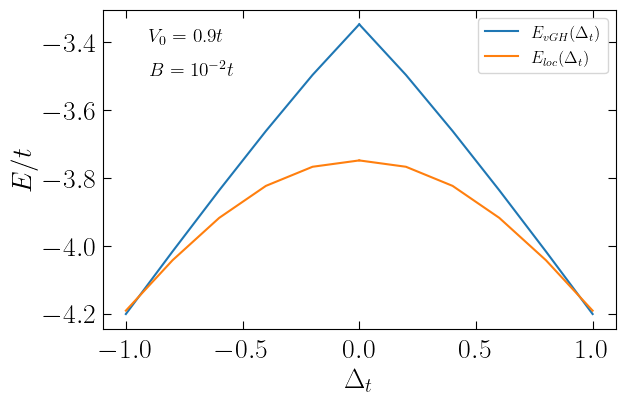

In [288]:
#e_gs_vgh - e_arr
delta_t_arr = tx_arr-ty_arr

i = 10
x_fit = np.append(-delta_t_arr, delta_t_arr)
y_fit = np.append(e_arr.T[i].real, e_arr.T[i].real)

z_fit = np.polyfit(x_fit, y_fit, 2)
p = np.poly1d(z_fit)
print('Quadratic Fit:', p)

x_fitd = np.linspace(-delta_t_arr[-1], delta_t_arr[-1],100)
y_fitd = p(x_fitd)

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20 # 14

fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

i = 10
print("V0 = ", V_0_arr[i])
plt.plot(delta_t_arr, e_gs_vgh.T[i].real, color='tab:blue', label=r'$E_{vGH}(\Delta_t)$')
plt.plot(-delta_t_arr, e_gs_vgh.T[i].real, color='tab:blue')

plt.plot(delta_t_arr, e_arr.T[i].real, color='tab:orange', label=r'$E_{loc}(\Delta_t)$')
plt.plot(-delta_t_arr, e_arr.T[i].real, color='tab:orange')

#plt.plot(x_fitd, y_fitd, color='tab:grey', linestyle='dashed', alpha=0.8, label=r'quadratic fit')

ax.annotate(r'$V_0 = $ '+str(V_0_arr[i])+r'$t$', xy=(-0.9, -3.4), fontsize=0.7*font_size, color='black')
ax.annotate(r'$B = 10^{-2}t$', xy=(-0.9, -3.5), fontsize=0.7*font_size, color='black')
      
plt.xlabel(r'$\Delta_t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=0.6*font_size)
plt.savefig('img_results/pseudo_jahn_teller_vgh_loc.svg', bbox_inches='tight', dpi=500, transparent=True)

### $\kappa_{crit}$ as a function of $V_0$

[-2.40677736e-15 -2.21983337e-03 -8.94318887e-03 -3.68768351e-02
 -3.57760227e-01 -5.57518900e-01 -5.97107815e-01 -5.77165208e-01
 -5.44409079e-01 -5.06638121e-01 -4.70320700e-01 -4.37818625e-01
 -3.84347755e-01 -3.41865374e-01 -3.06954155e-01 -2.77775740e-01
 -2.53081574e-01 -2.31945516e-01 -2.13665310e-01 -1.97703873e-01
 -1.83647155e-01 -1.71172820e-01 -1.60027059e-01 -1.50007692e-01]


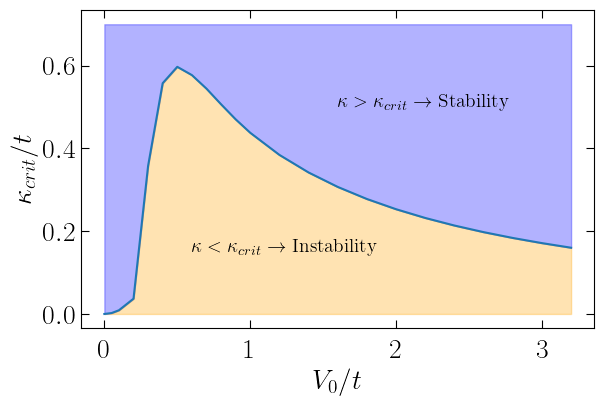

In [513]:
#e_gs_vgh - e_arr
delta_t_arr = tx_arr-ty_arr

def get_curvature_delta_t(delta_t_arr, e_arr):
    d2E_dD2 = np.zeros(e_arr.shape[1])
    for i in range(e_arr.shape[1]):
        x_fit = np.append(-delta_t_arr[1:4][::-1], delta_t_arr[0:4])
        y_fit = np.append(e_arr.T[i].real[1:4][::-1], e_arr.T[i].real[0:4])

        z_fit = np.polyfit(x_fit, y_fit, 2)
        d2E_dD2[i] = z_fit[0]
        
        #p = np.poly1d(z_fit)
        #print('Quadratic Fit:', p)

        #x_fitd = np.linspace(-delta_t_arr[-1], delta_t_arr[-1],100)
        #y_fitd = p(x_fitd)
    return d2E_dD2
    
delta_t_arr = tx_arr-ty_arr
m = 1

d2E_dD2 = get_curvature_delta_t(delta_t_arr, e_vgh_loc)
omega_crit = (np.abs(2*d2E_dD2)/m)**0.5

print(d2E_dD2)

i = 20
x_fit = np.append(-delta_t_arr[1:4][::-1], delta_t_arr[0:4])
y_fit = np.append(e_arr.T[i].real[1:4][::-1], e_arr.T[i].real[0:4])


A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20 # 14

fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

#plt.plot(V_0_arr[6:-1], omega_crit[6:-1], label=r'$E_{vGH}(\Delta_t)$')
plt.plot(V_0_arr[0:-1], -d2E_dD2[0:-1], label=r'$B = 10^{}$')

#plt.plot(x_fitd, y_fitd, color='tab:grey', linestyle='dashed', alpha=0.8, label=r'quadratic fit')

ax.fill_between(V_0_arr[0:-1], 0.7*np.ones(len(V_0_arr[0:-1])), -d2E_dD2[0:-1], interpolate=True, color='blue', alpha=0.3)
ax.fill_between(V_0_arr[0:-1], -d2E_dD2[0:-1], 0.0*np.ones(len(V_0_arr[0:-1])), interpolate=True, color='orange', alpha=0.3)

ax.annotate(r'$\kappa < \kappa_{crit} \rightarrow$ Instability', xy=(0.6,0.15), fontsize=0.7*font_size, color='black')
ax.annotate(r'$\kappa > \kappa_{crit} \rightarrow$ Stability', xy=(1.6,0.5), fontsize=0.7*font_size, color='black')
      
plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\kappa_{crit}/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

#plt.legend(fontsize=0.6*font_size)
plt.savefig('img_results/pseudo_jahn_teller_vgh_loc.svg', bbox_inches='tight', dpi=500, transparent=True)

## Jahn-Teller Schematics FDW

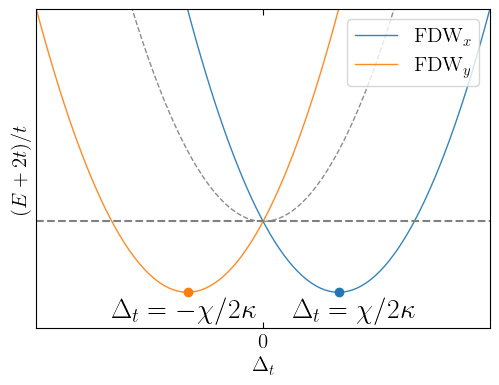

In [40]:
a = 1
b = 2

x = np.linspace(-3,3,100)
y1 = a*x**2 - b*x
y2 = a*x**2 + b*x

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 15

fig, ax = plt.subplots(figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
#ax.set_aspect("equal")

#plt.title(r'Jahn', fontsize=font_size)

plt.plot(x, a*x**2, linewidth=1, linestyle='dashed', color='grey', alpha=0.9)

plt.plot(x, y1, label=r'FDW$_x$', linewidth=1, alpha=0.9)
plt.scatter(b/(2*a), -1, marker='o')

plt.plot(x, y2, label=r'FDW$_y$', linewidth=1, alpha=0.9)
plt.scatter(-b/(2*a), -1, marker='o')


plt.xlabel(r'$\Delta_t$', fontsize=font_size)
plt.ylabel(r'$(E+2t)/t$', fontsize=font_size)

plt.hlines(y=0, xmin=-3, xmax=3, color='grey', linestyle='dashed')
#plt.vlines(x=0, ymin=-1.5, ymax=3, color='grey')
plt.xlim(-3,3)
plt.ylim(-1.5,3)
#plt.xticks([0.535,0.5375,0.54,0.5425,0.545,0.5475,0.55,0.5525,0.555],[r'0.535',r'',r'0.540',r'',r'0.545',r'',r'0.550',r'',r'0.555'],fontsize=font_size)

plt.annotate(r'$\Delta_t = \chi/2\kappa$', (0.4,-1.35), fontsize=20)
plt.annotate(r'$\Delta_t = -\chi/2\kappa$', (-2,-1.35), fontsize=20)

plt.xticks([0],[r'0'],fontsize=font_size)
plt.yticks([],[],fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=font_size, loc=1)
#plt.savefig('results/phase_diagram/jahn_teller_schematics.svg')

Quadratic Fit:          2
-0.4449 x - 3.752
Stiffness Parabola:      4
0.8 x
V0 =  0.9


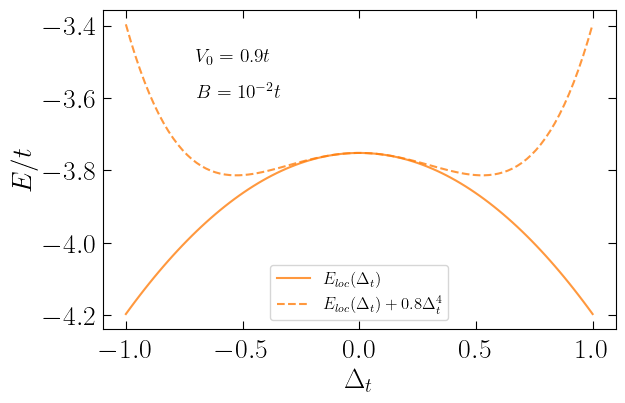

In [270]:
#e_gs_vgh - e_arr
delta_t_arr = tx_arr-ty_arr

'''Polynomial Fit to localized Ansatz:'''
i = 10
x_fit = np.append(-delta_t_arr, delta_t_arr)
y_fit = np.append(e_arr.T[i].real, e_arr.T[i].real)

z_fit = np.polyfit(x_fit, y_fit, 2)
p = np.poly1d(z_fit)

p_stiff = np.poly1d(np.array([0.8,0,0,0,0])) #np.poly1d(np.array([0.4,0,0]))

print('Quadratic Fit:', p)
print('Stiffness Parabola:', p_stiff)

x_fitd = np.linspace(-delta_t_arr[-1], delta_t_arr[-1],100)
y_fitd = p(x_fitd)

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20 # 14

fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

i = 10
print("V0 = ", V_0_arr[i])
#plt.plot(delta_t_arr, e_gs_vgh.T[i].real, color='tab:blue', label=r'$E_{vGH}(\Delta_t)$')
#plt.plot(-delta_t_arr, e_gs_vgh.T[i].real, color='tab:blue')

#plt.plot(delta_t_arr, e_arr.T[i].real, color='tab:orange', label=r'$E_{loc}(\Delta_t)$')
#plt.plot(-delta_t_arr, e_arr.T[i].real, color='tab:orange')

plt.plot(x_fitd, y_fitd, color='tab:orange', alpha=0.8, label=r'$E_{loc}(\Delta_t)$')
plt.plot(x_fitd, p_stiff(x_fitd)+y_fitd, color='tab:orange', linestyle='dashed', alpha=0.8, label=r'$E_{loc}(\Delta_t) + 0.8\Delta_t^4$')

#plt.plot(x_fitd, p_stiff(x_fitd)-3.7, color='tab:grey', linestyle='dashed', alpha=0.8, label=r'Quartic Potential')

ax.annotate(r'$V_0 = $ '+str(V_0_arr[i])+r'$t$', xy=(-0.7, -3.5), fontsize=0.7*font_size, color='black')
ax.annotate(r'$B = 10^{-2}t$', xy=(-0.7, -3.6), fontsize=0.7*font_size, color='black')
      
plt.xlabel(r'$\Delta_t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=0.6*font_size)
plt.savefig('img_results/pseudo_jahn_teller_loc_schematic.svg', bbox_inches='tight', dpi=500, transparent=True)

TODO:

- scan for longer coupling strengths

# Comparison vGH - Localized - Lang Firsov Perturbation Theory

Excitation Cutoff N=40:
V_0, N_cutoff = 0.5 , 40 ; E0 = -1.802532491522655 , E1 = -0.0013642033353931105 , E2 = -1.1852277802577416
V_0, N_cutoff = 0.6 , 40 ; E0 = -2.183440533403857 , E1 = -0.0007275861783986315 , E2 = -0.9781668312387262
V_0, N_cutoff = 0.8 , 40 ; E0 = -2.9495432587664676 , E1 = -0.00024065020750896338 , E2 = -0.7240069633998587
V_0, N_cutoff = 1.0 , 40 ; E0 = -3.719679994628302 , E1 = -9.153164836650518e-05 , E2 = -0.5741554081403204
V_0, N_cutoff = 1.2 , 40 ; E0 = -4.492682010605715 , E1 = -3.8393897440869296e-05 , E2 = -0.47543698107035315
V_0, N_cutoff = 1.4 , 40 ; E0 = -5.267855097777307 , E1 = -1.7331487789817857e-05 , E2 = -0.4055401800780629
V_0, N_cutoff = 1.6 , 40 ; E0 = -6.044746970858623 , E1 = -8.288077500751001e-06 , E2 = -0.35347373020715
V_0, N_cutoff = 1.8 , 40 ; E0 = -6.823043486334374 , E1 = -4.153466663936456e-06 , E2 = -0.3131993244611513
V_0, N_cutoff = 2.0 , 40 ; E0 = -7.6025159263517335 , E1 = -2.1642469381077944e-06 , E2 = -0.2811258583583198

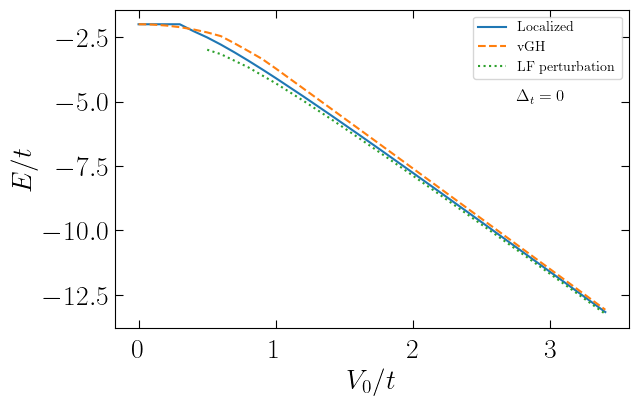

In [20]:
def read_pert_result(dir,V_0,B,tx,ty):
    file_path = dir+'data_V0_'+str(V_0)+'_B_'+str(B)+'_tx_'+str(tx)+'_ty_'+str(ty)+'.h5'

    with h5py.File(file_path, 'r') as f:
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        n_cutoff = f["N_cutoff"][...]
        e0 = f["e0"][...]
        e1 = f["e1"][...]
        e2 = f["e2"][...]

    return n_cutoff,e0,e1,e2

def read_for_cutoff(dir,V_0_arr,B,tx,ty):
    e0_arr = np.zeros(len(V_0_arr), dtype=complex)
    e1_arr = np.zeros(len(V_0_arr), dtype=complex)
    e2_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        n_cutoff,e0,e1,e2 =  read_pert_result(dir,V_0_arr[i],B,tx,ty)

        e0_arr[i] = e0
        e1_arr[i] = e1
        e2_arr[i] = e2

        print('V_0, N_cutoff =',V_0_arr[i],',',n_cutoff[0],'; E0 =',e0.real,', E1 =',e1.real-e0.real,', E2 =',e2.real-e1.real)

    return e0_arr, e1_arr, e2_arr

V_0_arr_lf = np.array([0.5,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.4]) #np.array([0.5,0.7,0.9,1.1,1.3,1.5,1.7,1.9,2.1]) #,0.7,0.9,1.1])

B = 0.01
tx = 0.5
ty = 0.5

print('Excitation Cutoff N=40:')
dir = 'data_lang_firsov/'
e0_cutoff_40, e1_cutoff_40, e2_cutoff_40 = read_for_cutoff(dir,V_0_arr_lf,B,tx,ty)

'''Plot'''
fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

i = 0
plt.plot(V_0_arr, e_arr[i].real, linestyle='solid', label=r'Localized')
plt.plot(V_0_arr_vgh, e_gs_vgh[i].real, linestyle='dashed', label=r'vGH')
plt.plot(V_0_arr_lf, e2_cutoff_40.real, linestyle='dotted', label=r'LF perturbation')

ax.annotate(r'$\Delta_t = 0$', xy=(2.75, -5), fontsize=0.6*font_size, color='black')
    
plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$E/t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=0.5*font_size)
plt.savefig('img_results/comp_vgh_loc_energies.svg', bbox_inches='tight', dpi=500, transparent=True)

# Wavefunction Characteristics

In [126]:
V_0_wfn = 0.4

Mx_wfn = 20
My_wfn = 20
tx_wfn = 0.6
ty_wfn = 0.4
B_wfn = 1e-2

dir = 'data_localized/'
x_angle, rot_wfn, ele_wfn, e_wfn, e_tun_wfn, e_B_wfn, e_V_wfn, Tx_wfn, Ty_wfn = get_wfn_loc_for_coupling(dir=dir,Mx=Mx_wfn,My=My_wfn,tx=tx_wfn,ty=ty_wfn,B=B_wfn,V_0=V_0_wfn)

print('E     =', e_wfn, '\nE_tun =', e_tun_wfn, '\nE_B   =', np.sum(e_B_wfn), '\nE_V   =', np.sum(e_V_wfn), '\nTx    =', Tx_wfn, '\nTy    =', Ty_wfn)

E     = (-2.291320730782453+5.147163652992713e-20j) 
E_tun = (-1.513444253779719+0j) 
E_B   = (0.12224872092110717+5.147163652992713e-20j) 
E_V   = -0.9001251979238413 
Tx    = (1.7018952430437118+0j) 
Ty    = (1.2307677698837354+0j)


0.6389530552474862


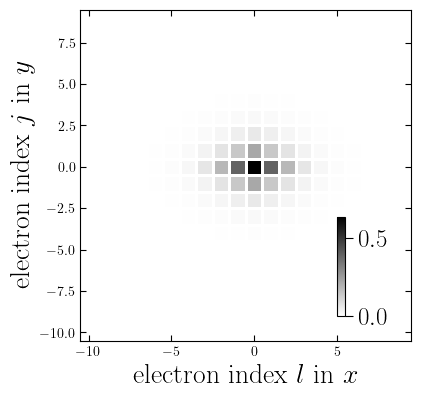

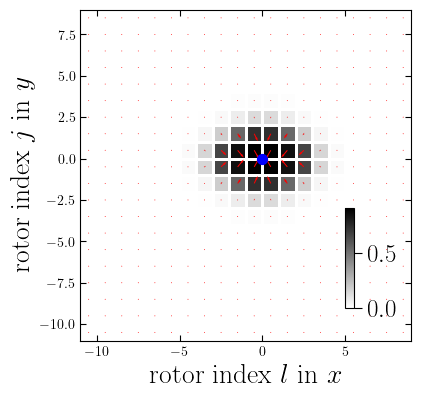

In [127]:
P_rotwfn, Px_rotwfn, Py_rotwfn = Px_Py_rotwfn(x_angle,Mx,My,rot_wfn.T)

'''
Electron Wavefunction
'''
x_arr = np.arange(-int(Px_plot.shape[0]/2),int(Px_plot.shape[0]/2),1)
X, Y = np.meshgrid(x_arr, x_arr) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc = plt.pcolormesh(X, Y, ele_wfn.real.T, cmap='binary', vmin=0.0, snap=True)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

print(np.max(ele_wfn.real.T))

cax = ax.inset_axes([5, -9, 0.5, 6], transform=ax.transData)
cbar = fig.colorbar(pc, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc.set_edgecolor('white')

plt.xlabel(r'electron index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'electron index $j$ in $y$', fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

#plt.savefig('results/configurations/pol_size/p_vec_fo.svg')

'''
Rotor Wavefunction
'''

P_plot = P_rotwfn
Px_plot = Px_rotwfn
Py_plot = Py_rotwfn

x_arr = np.arange(-int(Px_plot.shape[0]/2),int(Px_plot.shape[0]/2),1)-0.5
X, Y = np.meshgrid(x_arr, x_arr) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc = plt.pcolormesh(X, Y, P_plot.real, cmap='binary', vmin=0.0, snap=True)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([5, -9, 0.5, 6], transform=ax.transData)
cbar = fig.colorbar(pc, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc.set_edgecolor('white')

'''Polarization Vector Plot'''
q = plt.quiver(X, Y, -Py_plot, -Px_plot, color='red', scale=30, headlength=3, headwidth=2)
#ax.invert_yaxis()

ax.scatter(-0, 0., marker='o', s=50, color='blue', alpha=1, zorder=2)
#ax.annotate(r'(c) $V_0/t=0.5$, FLP', xy=(0.2, -0.1), xytext=(-4.4, 3.8), fontsize=20, color='black')

plt.xlabel(r'rotor index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'rotor index $j$ in $y$', fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

#plt.savefig('results/configurations/pol_size/p_vec_fo.svg')

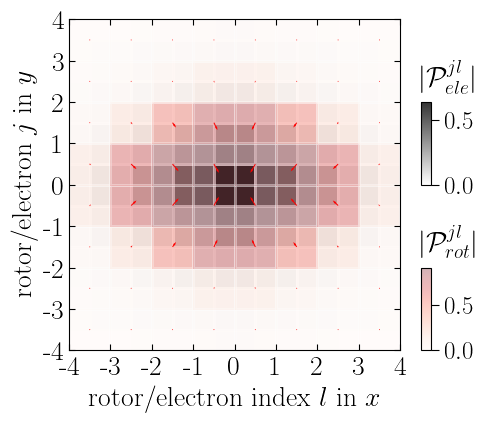

In [133]:
'''
Rotor Wavefunction
'''

P_plot = P_rotwfn
Px_plot = Px_rotwfn
Py_plot = Py_rotwfn

x_arr_ele = np.arange(-int(Px_plot.shape[0]),int(Px_plot.shape[0]),2)
X_ele, Y_ele = np.meshgrid(x_arr_ele, x_arr_ele) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

x_arr_rot = np.arange(-int(Px_plot.shape[0]),int(Px_plot.shape[0]),2)-0.5
X_rot, Y_rot = np.meshgrid(x_arr_rot, x_arr_rot) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc1 = plt.pcolormesh(X_ele, Y_ele, ele_wfn.real.T, cmap='binary', vmin=0.0, snap=True, alpha=0.8)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))
pc2 = plt.pcolormesh(X_rot-0.5, Y_rot-0.5, P_plot.real, cmap='Reds', vmin=0.0, snap=True, alpha=0.3)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([9, 0, 0.5, 4], transform=ax.transData)
cbar = fig.colorbar(pc1, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$|P_{ele}|$', size=font_size)
ax.annotate(r'$|\mathcal{P}_{ele}^{jl}|$', xy=(8, 3), xytext=(9, 4.8), fontsize=20, color='black')
ax.annotate(r'$|\mathbf{\mathcal{P}}_{rot}^{jl}|$', xy=(8, 1), xytext=(9, -3.2), fontsize=20, color='black')
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc1.set_edgecolor('white')

cax = ax.inset_axes([9, -8, 0.5, 4], transform=ax.transData)
cbar = fig.colorbar(pc2, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc2.set_edgecolor('white')

'''Polarization Vector Plot'''
q = plt.quiver(X_rot-0.5, Y_rot-0.5, -Py_plot, -Px_plot, color='red', scale=30, headlength=3, headwidth=2)
#ax.invert_yaxis()

#ax.scatter(-0.5, -0.5, marker='o', s=50, color='blue', alpha=1, zorder=2)
#ax.annotate(r'(c) $V_0/t=0.5$, FLP', xy=(0.2, -0.1), xytext=(-4.4, 3.8), fontsize=20, color='black')

plt.xlabel(r'rotor/electron index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'rotor/electron $j$ in $y$', fontsize=font_size)

plt.xticks([-8,-6,-4,-2,0,2,4,6,8],[r'-4',r'-3',r'-2',r'-1',r'0',r'1',r'2',r'3',r'4'], fontsize=font_size)
plt.yticks([-8,-6,-4,-2,0,2,4,6,8],[r'-4',r'-3',r'-2',r'-1',r'0',r'1',r'2',r'3',r'4'], fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

plt.xlim(-8,8)
plt.ylim(-8,8)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

plt.savefig('img_results/loc_wavefunc_delta_t_-0.2_V0_0.4.svg', bbox_inches='tight')

# Effective Mass Calculation

In [ ]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_m = np.array([0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0])

Mx = 20
My = 20
tx_arr_m = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_m = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B = 1e-2

mx, my = get_eff_mass_arr(tx_arr_m,ty_arr_m,V_0_arr_m,Mx,My,B)

tx, ty, V_0, m_x, m_y = 0.5 0.5 0.4 (-2.2870251891099524-1.0570282323524497e-19j) (977.3020796790246-4.1845670483118714e-15j) (977.3020796790196+1.1883712378772474e-14j)
tx, ty, V_0, m_x, m_y = 0.5 0.5 0.6 (-2.7928357105989607+9.267253006707649e-19j) (6988.678648243406+2.850671716048691e-14j) (6988.67864824536-7.572042064607022e-14j)
tx, ty, V_0, m_x, m_y = 0.5 0.5 0.8 (-3.415218100583223-7.211727299874396e-19j) (27649.42991136093+1.1013411897285953e-13j) (27649.429911370193-1.5670727745521386e-13j)
tx, ty, V_0, m_x, m_y = 0.5 0.5 1.0 (-4.09155701391214-8.390573359722417e-19j) (65639.32056335126+2.1588140996060893e-13j) (65639.3205630757-3.8291073919120444e-13j)
tx, ty, V_0, m_x, m_y = 0.5 0.5 1.2 (-4.799012381553753+7.247959629284337e-19j) (108749.76821798005-5.185897467556423e-13j) (108749.76821796433-9.517368494590848e-15j)
tx, ty, V_0, m_x, m_y = 0.5 0.5 1.4 (-5.526201947289707+1.1990984505559464e-18j) (143313.31529124206-2.9168011782528987e-13j) (143313.31529127003+7.6980069161595

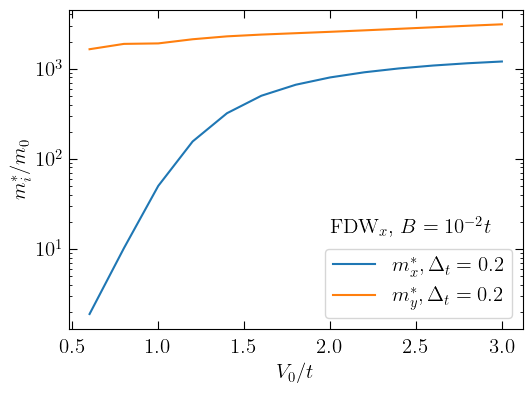

In [406]:
A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 15

fig, ax = plt.subplots() #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)], subplot_kw={"projection": "3d"})
#ax.set_aspect("equal")

plt.plot(V_0_arr_m[1:], mx[2][1:].real/mx[2][0].real, label=r'$m_x^*, \Delta_t = 0.2$')
plt.plot(V_0_arr_m[1:], my[2][1:].real/mx[2][0].real, label=r'$m_y^*, \Delta_t = 0.2$')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$m_i^*/m_0$', fontsize=font_size)

#plt.xscale('log')
plt.yscale('log')

ax.annotate(r'FDW$_x$, $B=10^{-2}t$', xy=(2.0, 15), fontsize=font_size, color='black')
#plt.yticks([1e-3,1,2,3],[r'$10^{-3}$',r'1',r'$2$',r'$3$'], fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=font_size)
plt.savefig('img_results/eff_mass_loc.svg', bbox_inches='tight')

inf


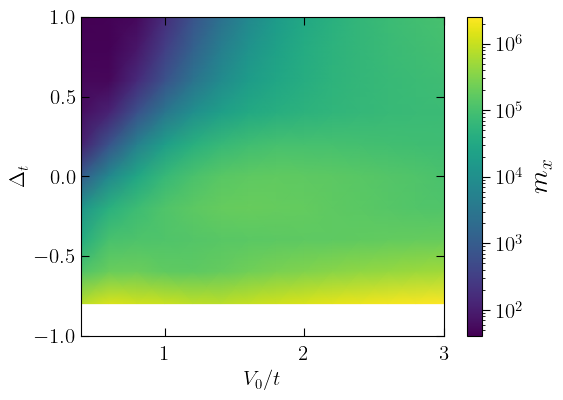

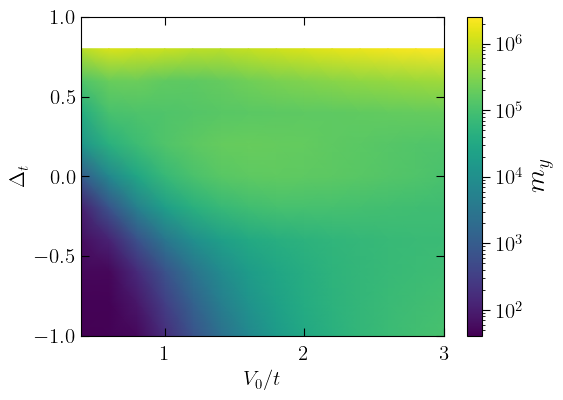

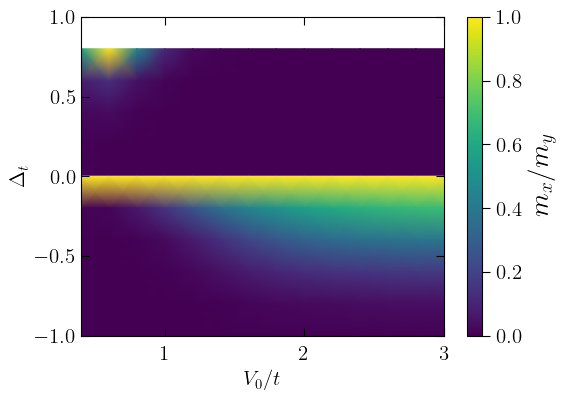

In [51]:
X, Y = np.meshgrid(V_0_arr_m, tx_arr-ty_arr)

import matplotlib.colors as colors

print(my.real.max())
'''mx'''
pc = plt.pcolormesh(X,Y,mx.real, antialiased=False, shading='gouraud', norm=colors.LogNorm(vmin=mx.real.min(), vmax=my[-2].real.max())) # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,my.real, antialiased=False, shading='gouraud', norm=colors.LogNorm(vmin=mx.real.min(), vmax=my[-2].real.max())) # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$m_x$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
plt.show() 

'''my'''
pc = plt.pcolormesh(X,Y,my.real, antialiased=False, shading='gouraud', norm=colors.LogNorm(vmin=mx.real.min(), vmax=my[-2].real.max())) # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,mx.real, antialiased=False, shading='gouraud', norm=colors.LogNorm(vmin=mx.real.min(), vmax=my[-2].real.max())) # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$m_y$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
plt.show() 

'''mx/my'''
pc = plt.pcolormesh(X,Y,my.real/mx.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
pc = plt.pcolormesh(X,-Y,mx.real/my.real, antialiased=False, shading='gouraud') # cmap='gnuplot',
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$m_x/m_y$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)
plt.show() 

# Finite Size Convergence

In [57]:
'''
Size 1: Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_s1 = np.array([0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])

Mx_s1 = 20
My_s1 = 20
tx_arr_s1 = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_s1 = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B_s1 = 1e-2

qx_s1=0.0
qy_s1=0.0

dir='data_localized/'
e_arr_s1, e_tun_arr_s1, e_T_arr_s1, e_B_arr_s1, e_V_arr_s1, Tx_arr_s1, Ty_arr_s1 = get_state_e_loc_data(dir=dir,Mx=Mx_s1,My=My_s1,tx_arr=tx_arr_s1,ty_arr=ty_arr_s1,B=B_s1,V_0_arr=V_0_arr_s1)

In [58]:
'''
Size 2: Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr_s2 = np.array([0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0])

Mx_s2 = 40
My_s2 = 40
tx_arr_s2 = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr_s2 = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B_s2 = 1e-2

qx_s2=0.0
qy_s2=0.0

dir='data_localized/'
e_arr_s2, e_tun_arr_s2, e_T_arr_s2, e_B_arr_s2, e_V_arr_s2, Tx_arr_s2, Ty_arr_s2 = get_state_e_loc_data(dir=dir,Mx=Mx_s2,My=My_s2,tx_arr=tx_arr_s2,ty_arr=ty_arr_s2,B=B_s2,V_0_arr=V_0_arr_s2)

In [59]:
diff_e_s1_s2 = e_arr_s2 - e_arr_s1

print('delta E max =', np.max(diff_e_s1_s2))
print('delta E min =', np.min(diff_e_s1_s2))

delta E max = (7.223149055013423e-05-4.988428871156299e-20j)
delta E min = (-8.683187502356304e-11-1.7931080296624327e-18j)


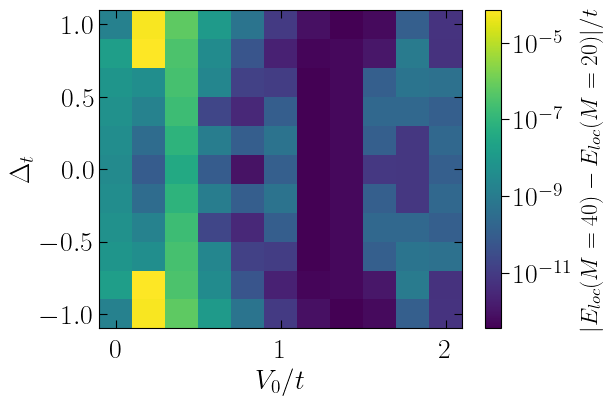

In [60]:
import matplotlib.colors as colors

X, Y = np.meshgrid(V_0_arr_s1, tx_arr_s1-ty_arr_s1)

Z = np.abs(diff_e_s1_s2.real)

pc = plt.pcolormesh(X,Y,Z, antialiased=False, norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max())) 
pc = plt.pcolormesh(X,-Y,Z, antialiased=False, norm=colors.LogNorm(vmin=Z.min(), vmax=Z.max()))
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$|E_{loc}(M=40)-E_{loc}(M=20)|/t$', size=17)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

TODO: put here analysis of comparing the diagonalization of the translated basis states.

TODO: put here the energy comparison after the diagonalization!

In [ ]:
Put here the diagonalization